# Notebook 2: Ontology Design

In this notebook, I explain the design of the knowledge graph ontology, from MIT's topic taxonomy to a graph schema with typed nodes, hierarchical relationships, and co-occurrence edges.

The design follows an established ontology engineering methodology (Grüninger & Fox, 1995): starting from motivating scenarios, formulating competency questions, and deriving the ontology directly from them. The three use cases defined in Notebook 1 are those motivating scenarios:

1. **Semantic course search** — finding courses through natural language queries about topics and content
2. **Relationship-focused queries** — questions that need instructor connections, topic traversal, and property filtering
3. **Graph analytics** — centrality, clustering, and similarity analysis

Each competency question derived from these use cases is directly related to elements in the ontology. Following this approach driven by use cases, every node type, relationship, and property exists because at least one question requires it. Anything else would increase overhead without adding value.

---
## Starting point: MIT's taxonomy

MIT Learn organizes course topics using a two-level topic taxonomy: 11 broad parent categories, each containing specific child topics. This structure is a nice starting point to develop an ontology.

A taxonomy is a hierarchical classification (parent-child). An ontology adds:
- **Typed entities** beyond just topics (courses and instructors)
- **Named relationships** between different entity types
- **Properties** on both nodes and relationships
- **Cross-category relationships** that the hierarchy alone can't capture

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import Image

PROJECT_ROOT = Path('..')

In [2]:
# Load the full MIT topic hierarchy
hierarchy_df = pd.read_csv(PROJECT_ROOT / 'data' / 'curated' / 'topic_hierarchy.csv', sep=';')

# Load our course topics to identify which ones we actually use
courses_df = pd.read_csv(PROJECT_ROOT / 'data' / 'curated' / 'courses.csv')

our_topics = set()
for topics_str in courses_df['topics']:
    for t in topics_str.split(';'):
        t = t.strip()
        if t:
            our_topics.add(t)

print(f'MIT taxonomy: {len(hierarchy_df)} parent-child pairs')
print(f'Parents: {hierarchy_df["parent"].nunique()}')
print(f'Children: {hierarchy_df["child"].nunique()}')
print(f'Topics in our data: {len(our_topics)}')

MIT taxonomy: 99 parent-child pairs
Parents: 11
Children: 99
Topics in our data: 44


### Taxonomy tree

Let's take a look at the full MIT topic hierarchy. The topics highlighted in color appear in our course data; grey topics exist in the taxonomy, but are not covered by any of our 50 courses.

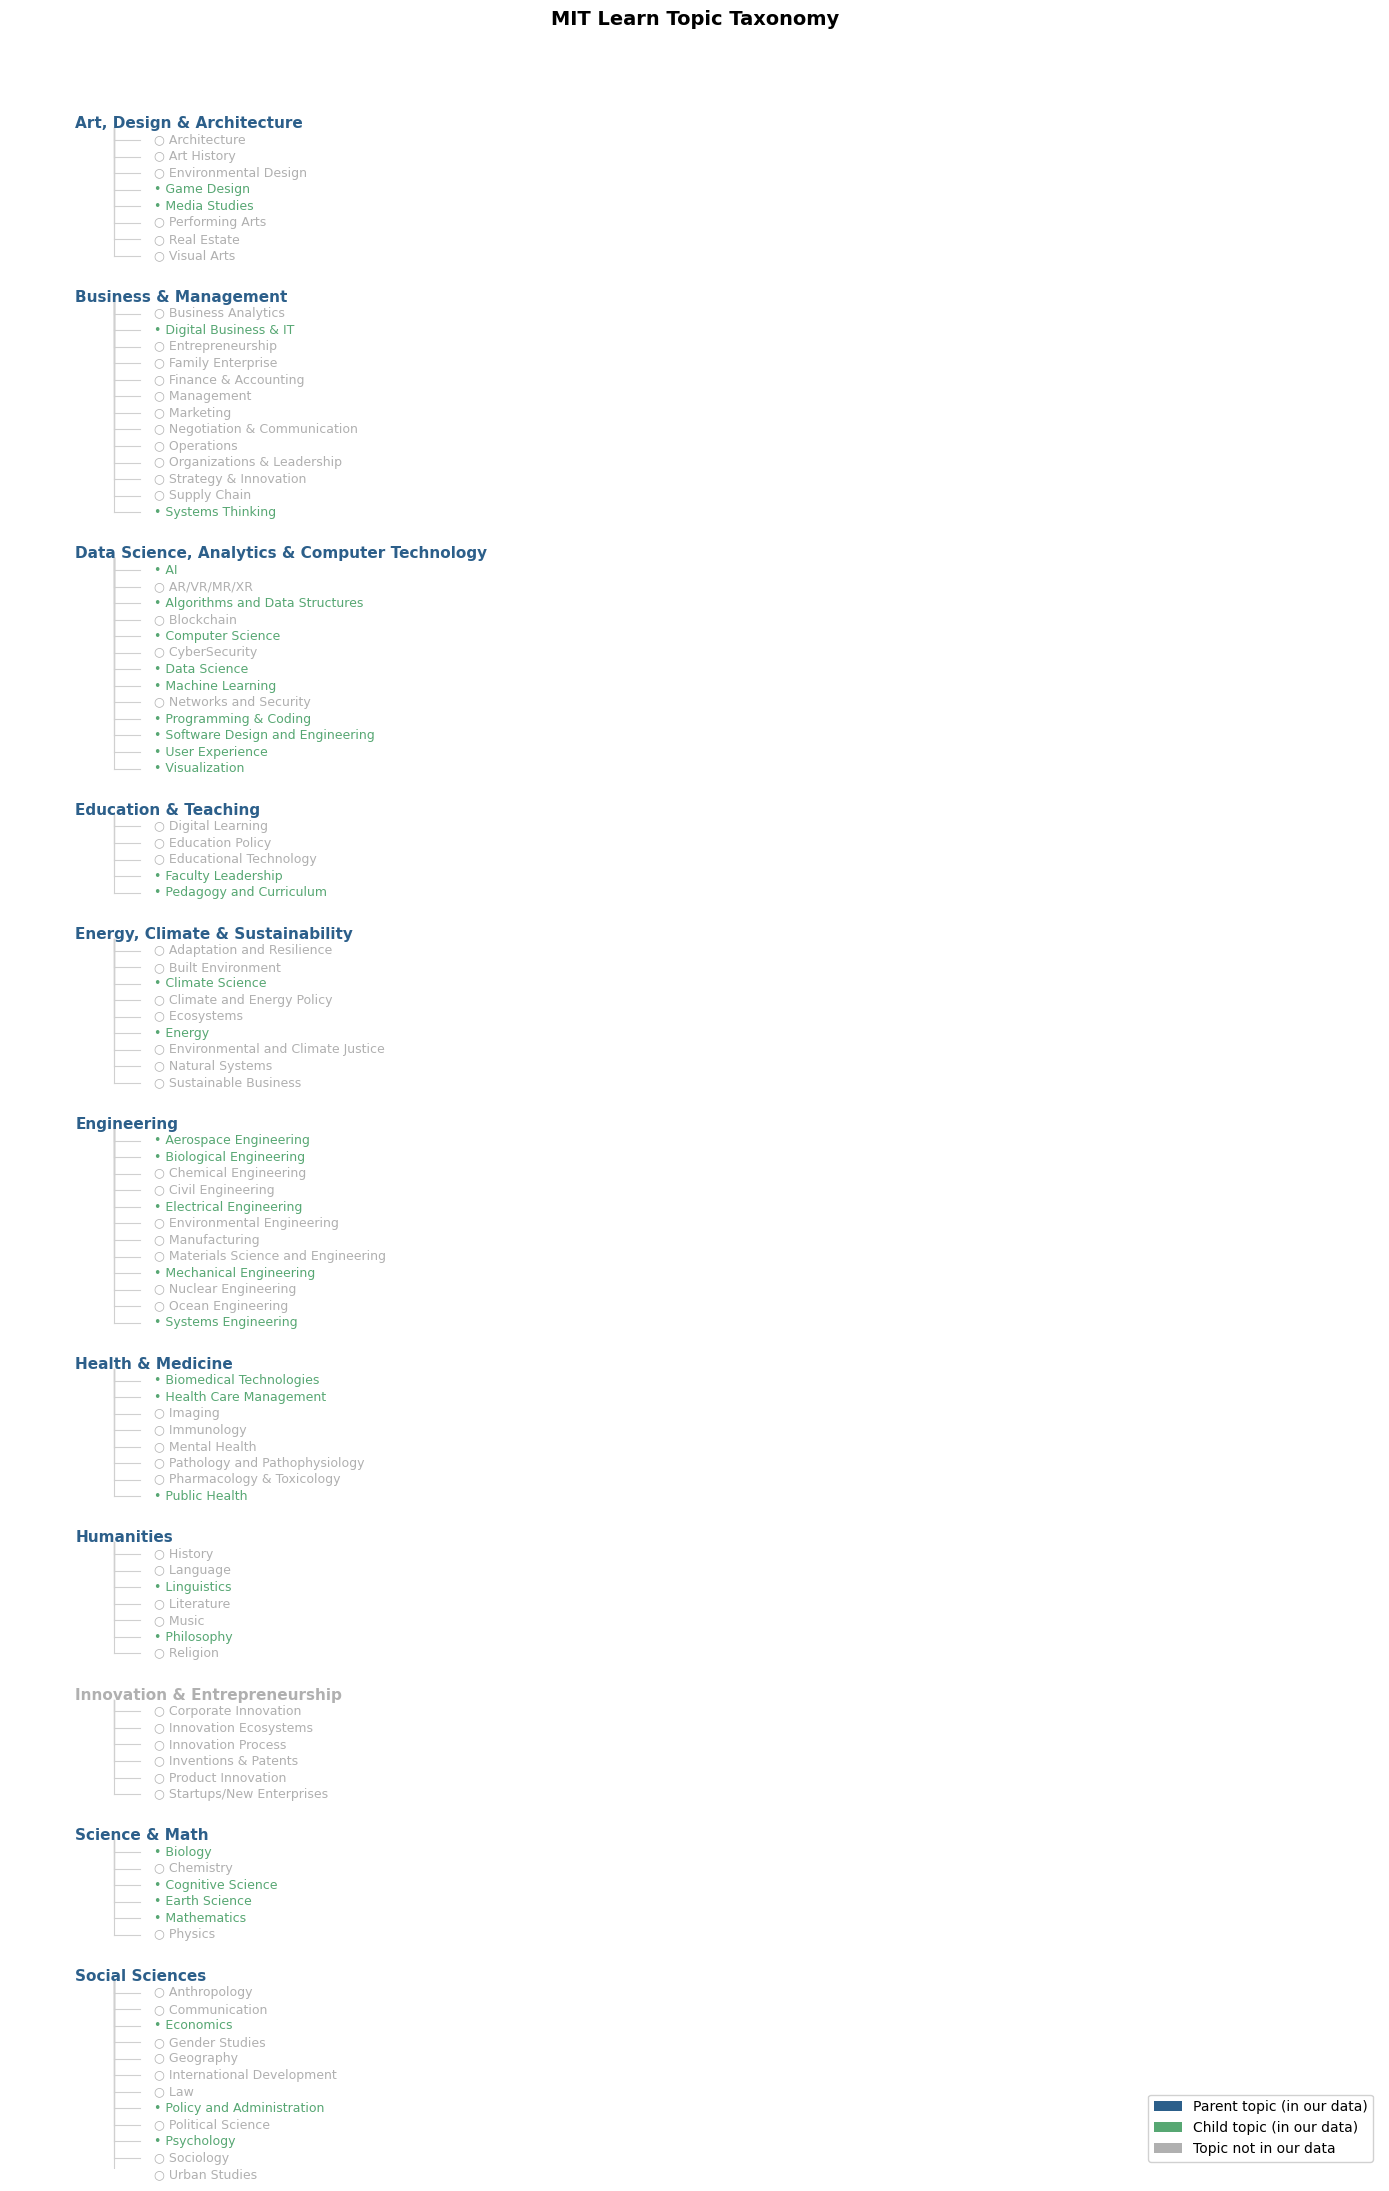

Saved to schema/taxonomy_tree.png


In [3]:
# Build the taxonomy tree visualization
parents = hierarchy_df['parent'].unique()

fig, ax = plt.subplots(figsize=(14, 22))
ax.set_xlim(-0.5, 10)
ax.axis('off')
fig.patch.set_facecolor('white')

y = 0
y_step = 0.35
parent_color = '#2C5F8A'
child_in_data = '#57A773'
child_not_in_data = '#B0B0B0'

for parent in sorted(parents):
    children = sorted(hierarchy_df[hierarchy_df['parent'] == parent]['child'].tolist())

    # Parent
    parent_weight = 'bold' if parent in our_topics else 'normal'
    parent_c = parent_color if parent in our_topics else child_not_in_data
    ax.text(0, -y, parent, fontsize=11, fontweight='bold', color=parent_c,
            verticalalignment='center')
    parent_y = y

    for child in children:
        y += y_step
        in_data = child in our_topics
        color = child_in_data if in_data else child_not_in_data
        marker = '•' if in_data else '○'

        # Connecting line
        ax.plot([0.3, 0.5], [-y, -y], color='#D0D0D0', linewidth=0.8)
        ax.plot([0.3, 0.3], [-parent_y - 0.1, -y], color='#D0D0D0', linewidth=0.8)

        ax.text(0.6, -y, f'{marker} {child}', fontsize=9, color=color,
                verticalalignment='center')

    y += y_step * 2.5  # gap between parent groups

# Legend
legend_elements = [
    mpatches.Patch(facecolor=parent_color, label='Parent topic (in our data)'),
    mpatches.Patch(facecolor=child_in_data, label='Child topic (in our data)'),
    mpatches.Patch(facecolor=child_not_in_data, label='Topic not in our data'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

ax.set_ylim(-y + 1, 1.5)
ax.set_title('MIT Learn Topic Taxonomy', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'schema' / 'taxonomy_tree.png'), dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Saved to schema/taxonomy_tree.png')

---
## From a taxonomy to an ontology

Although the taxonomy is a good starting point because of the topic classification provided, our use cases demand a richer semantic layer.

**Use case 1 (Semantic search)** needs courses connected to topics, so a user can find courses by topic. Therefore, `Course` and `Topic` were modeled as separate node types linked by a `HAS_TOPIC` relationship.

To handle **use case 2 (Relationship-focused queries)**, the ontology includes:
- `Instructor` nodes with `TAUGHT_BY` relationships, so we can answer "what else does this instructor teach?"
- `CHILD_OF` relationships between child and parent topics, so we can navigate the hierarchy ("show me all courses under Engineering")
- `RELATED_TO` relationships between child topics weighted by co-occurrence, so we can find topically related courses even when they don't share the exact same tags
- Properties like `year` on Course nodes, so we can filter and sort ("most recent courses on AI")

**Use case 3 (Graph analytics)** needs a connected graph with enough structure to make centrality, community detection, and similarity algorithms meaningful. The topic co-occurrence network (via `RELATED_TO`) and the bipartite course-topic graph (via `HAS_TOPIC`) provide this.

Each design decision is related to a specific use case need:

| Design decision | Justification |
|---|---|
| `Course` as a node | Enables relationship traversal and property filtering |
| `Topic` as a node (not a property) | Enables shared-topic queries, hierarchy, and co-occurrence |
| `Instructor` as a node (not a property) | 14 instructors teach multiple courses; the graph captures this |
| `HAS_TOPIC` relationship | Connects courses to topics for search and analytics |
| `TAUGHT_BY` relationship | Enables instructor-based queries |
| `CHILD_OF` relationship | Preserves MIT's hierarchical classification |
| `RELATED_TO` with weight | Captures co-occurrence strength for similarity and clustering |
| `level` property on Topic | Distinguishes parent from child without separate labels |

---
## Schema

The final ontology has three node types and four relationship types:

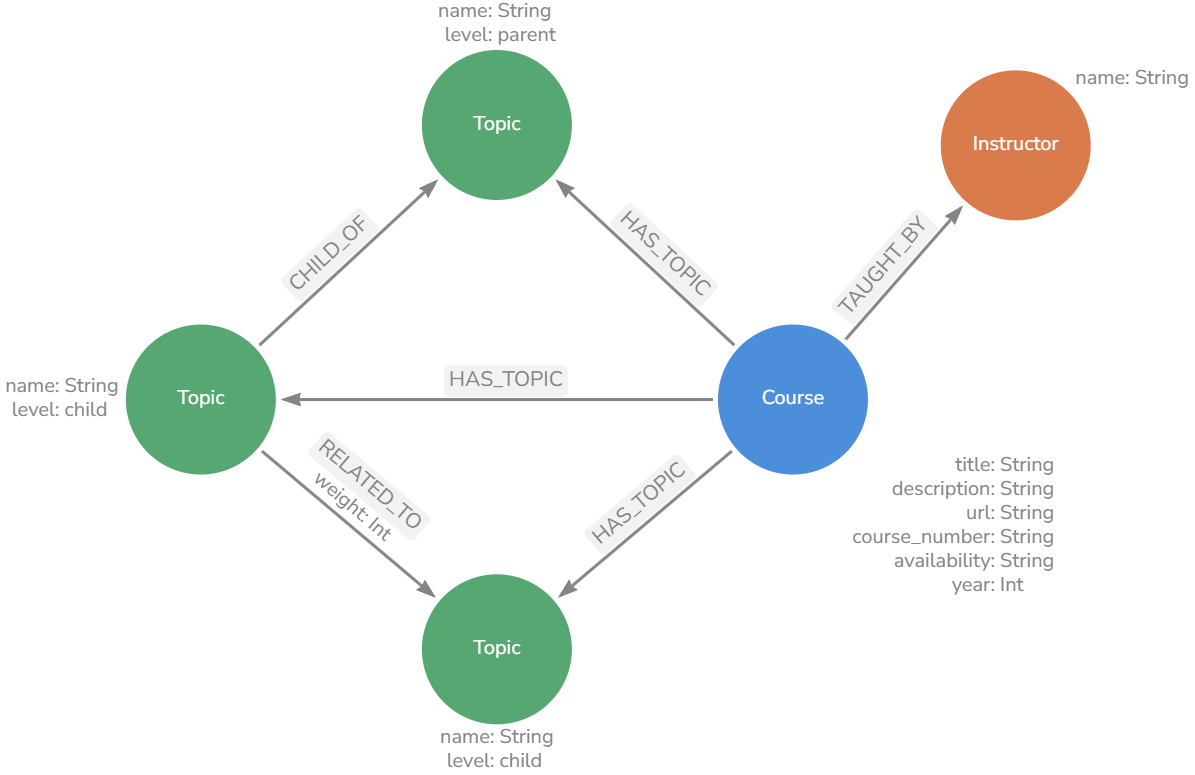

In [4]:
Image(filename=str(PROJECT_ROOT / 'schema' / 'courses-schema.png'), width=800)

**Nodes:**
- `Course`: title, description, url, course_number, availability, year
- `Topic`: name, level ("parent" or "child")
- `Instructor`: name

**Relationships:**
- `HAS_TOPIC`: Course to Topic
- `TAUGHT_BY`: Course to Instructor
- `CHILD_OF`: Child topic to parent topic (MIT's taxonomy)
- `RELATED_TO`: Between child-level topics, weighted by co-occurrence

The `RELATED_TO` relationship captures how often two child-level topics
appear together across courses, providing signal for the similarity use
case. It is stored as directed (a Neo4j requirement) but represents a
symmetric co-occurrence, so it is queried without direction.

---
## What the ontology adds over the raw data

| Raw CSV | Knowledge graph |
|---|---|
| Topics as a flat semicolon-separated string | Topics as nodes in a two-level hierarchy |
| No relationship between topics | Co-occurrence weights between child topics |
| Instructors as text in a cell | Instructor nodes connected to multiple courses |
| No way to traverse from one course to related courses | Multi-hop traversal via shared topics, instructors, hierarchy |
| Filtering requires pandas/SQL | Property-based filtering in Cypher |

This is the core argument for Graph RAG: the ontology encodes structure that the LLM can exploit to give more precise answers.

---
## Next Steps

In the next notebook, we load this ontology into Neo4j, create the nodes and relationships, and verify the graph structure.